In [44]:
import functions as fn
import numpy as np
from mastu import HSV
import matplotlib.pyplot as plt
import my_funcs as mf
from pyEquilibrium.equilibrium import equilibrium as equil
import pyuda
client = pyuda.Client()
from scipy.optimize import curve_fit

%matplotlib widget

Thomson time is 0.8001000s


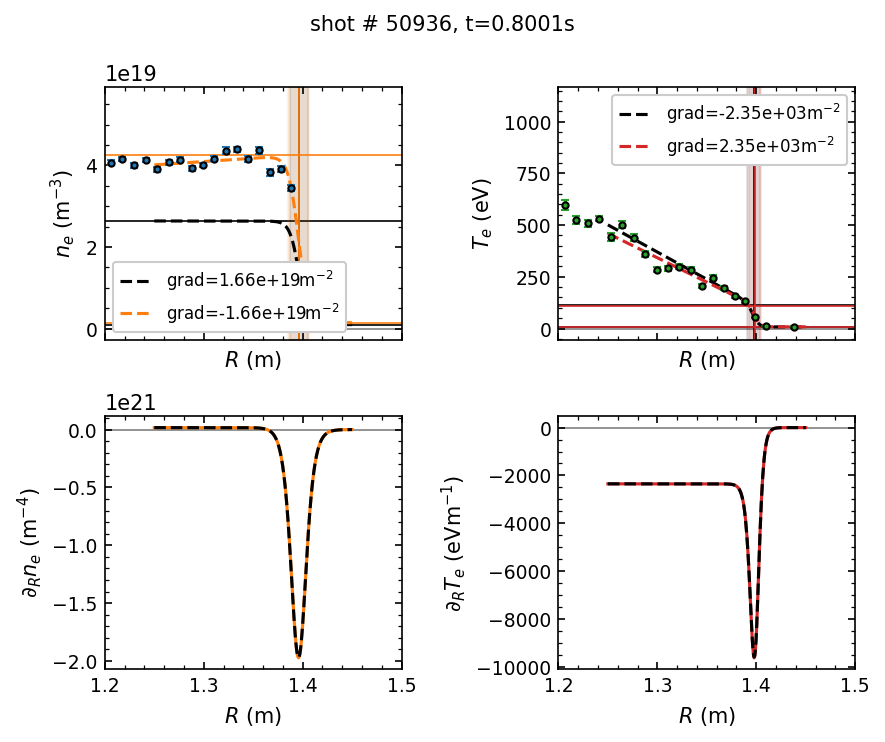

In [2]:
shotn = 50936
twant = 0.8
Rwant = 1.25
Rend = 1.45

time, ne, neErr, Rthomson = HSV.getThomson(shotn, 'n_e')
_, Te, TeErr, _ = HSV.getThomson(shotn, 'T_e')
time2, R0ne, heightne, widthne, gradne, bkgdne = HSV.getPedestal(shotn, 'n_e')
_, R0Te, heightTe, widthTe, gradTe, bkgdTe = HSV.getPedestal(shotn, 'T_e')

t = fn.findNearest(time, twant)
t2 = fn.findNearest(time2, twant)
print(f'Thomson time is {time[t]:.7f}s')
r = fn.findNearest(Rthomson[t], Rwant)
R = np.linspace(Rwant, Rend, 300)

profilene = HSV.mtanh(R, R0ne[t2], heightne[t2], widthne[t2], gradne[t2], bkgdne[t2])
profileTe = HSV.mtanh(R, R0Te[t2], heightTe[t2], widthTe[t2], gradTe[t2], bkgdTe[t2])

boone = np.isfinite(ne[t,r:])
xne = Rthomson[t,r:][boone]
yne = ne[t,r:][boone]
yErrne = neErr[t,r:][boone]
poptne, pcovne = curve_fit(
    HSV.mtanh, xne, yne, sigma=yErrne, absolute_sigma=True, 
    p0=(R0ne[t2],heightne[t2],widthne[t2],gradne[t2],bkgdne[t2])
)
profile2ne = HSV.mtanh(R, *poptne)

booTe = np.isfinite(Te[t,r:])
xTe = Rthomson[t,r:][booTe]
yTe = Te[t,r:][booTe]
yErrTe = TeErr[t,r:][booTe]
poptTe, pcovTe = curve_fit(
    HSV.mtanh, xTe, yTe, sigma=yErrTe, absolute_sigma=True, 
    p0=(R0Te[t2],heightTe[t2],widthTe[t2],gradTe[t2],bkgdTe[t2])
)
profile2Te = HSV.mtanh(R, *poptTe)

gradne = HSV.mtanhGradient(R, *poptne)
gradTe = HSV.mtanhGradient(R, *poptTe)
gradneNumerical = np.gradient(profile2ne, R)
gradTeNumerical = np.gradient(profile2Te, R)


xlim = (1.2, 1.5)

fig, ax = plt.subplots(2, 2, figsize=(6,5), dpi=150, sharex=True)
ax[0,0].errorbar(Rthomson[t], ne[t], yerr=neErr[t], fmt='.', c='C0', mec='k', capsize=2, zorder=3)
ax[0,0].plot(R, profilene, '--k', zorder=2, label=f'grad={gradne[t]:.3g}m$^{{-2}}$')
ax[0,0].plot(R, profile2ne, '--', c='C1', zorder=2, label=f'grad={poptne[-2]:.3g}m$^{{-2}}$')
ax[0,0].plot(xlim, [0.,0], '-', c='gray', lw=0.8, zorder=0)
ax[0,0].legend(fancybox=1, framealpha=1, fontsize=8)

ax[0,0].set_xlabel('$R$ (m)')
ax[0,0].set_ylabel('$n_e$ (m$^{-3}$)')
ax[0,0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0,0].minorticks_on()


ylimne = ax[0,0].get_ylim()
ax[0,0].set_xlim(xlim)
ax[0,0].set_ylim(ylimne)

ax[0,0].plot([R0ne[t2], R0ne[t2]], ylimne, '-k', lw=0.8, zorder=1)
ax[0,0].plot(xlim, [heightne[t2], heightne[t2]], '-k', lw=0.8, zorder=1)
ax[0,0].plot(xlim, [bkgdne[t2], bkgdne[t2]], '-k', lw=0.8, zorder=1)
ax[0,0].fill_between(
    [R0ne[t2]-widthne[t2]/2.,R0ne[t2]+widthne[t2]/2.,], 
    [ylimne[0],ylimne[0]], [ylimne[1],ylimne[1]], color='k', alpha=0.1
)

ax[0,0].plot([poptne[0], poptne[0]], ylimne, '-', c='C1', lw=0.8, zorder=1)
ax[0,0].plot(xlim, [poptne[1], poptne[1]], '-', c='C1', lw=0.8, zorder=1)
ax[0,0].plot(xlim, [poptne[-1], poptne[-1]], '-', c='C1', lw=0.8, zorder=1)
ax[0,0].fill_between(
    [poptne[0]-poptne[2]/2.,poptne[0]+poptne[2]/2.,], 
    [ylimne[0],ylimne[0]], [ylimne[1],ylimne[1]], color='C1', alpha=0.1
)

ax[0,1].errorbar(Rthomson[t], Te[t], yerr=TeErr[t], fmt='.', c='C2', mec='k', capsize=2, zorder=3)
ax[0,1].plot(R, profileTe, '--k', zorder=2, label=f'grad={gradTe[t]:.3g}m$^{{-2}}$')
ax[0,1].plot(R, profile2Te, '--', c='C3', zorder=2, label=f'grad={poptTe[-2]:.3g}m$^{{-2}}$')
ax[0,1].plot(xlim, [0.,0], '-', c='gray', lw=0.8, zorder=0)
ax[0,1].legend(fancybox=1, framealpha=1, fontsize=8)

ax[0,1].set_xlabel('$R$ (m)')
ax[0,1].set_ylabel('$T_e$ (eV)')
ax[0,1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0,1].minorticks_on()


ylimTe = ax[0,1].get_ylim()
ax[0,1].set_xlim(xlim)
ax[0,1].set_ylim(ylimTe)

ax[0,1].plot([R0Te[t2], R0Te[t2]], ylimTe, '-k', lw=0.8, zorder=1)
ax[0,1].plot(xlim, [heightTe[t2], heightTe[t2]], '-k', lw=0.8, zorder=1)
ax[0,1].plot(xlim, [bkgdTe[t2], bkgdTe[t2]], '-k', lw=0.8, zorder=1)
ax[0,1].fill_between(
    [R0Te[t2]-widthTe[t2]/2.,R0Te[t2]+widthTe[t2]/2.,], 
    [ylimTe[0],ylimTe[0]], [ylimTe[1],ylimTe[1]], color='k', alpha=0.1
)

ax[0,1].plot([poptTe[0], poptTe[0]], ylimTe, '-', c='C3', lw=0.8, zorder=1)
ax[0,1].plot(xlim, [poptTe[1], poptTe[1]], '-', c='C3', lw=0.8, zorder=1)
ax[0,1].plot(xlim, [poptTe[-1], poptTe[-1]], '-', c='C3', lw=0.8, zorder=1)
ax[0,1].fill_between(
    [poptTe[0]-poptTe[2]/2.,poptTe[0]+poptTe[2]/2.,], 
    [ylimTe[0],ylimTe[0]], [ylimTe[1],ylimTe[1]], color='C3', alpha=0.1
)

ax[1,0].plot(R, gradne, '-', c='C1', zorder=2, )
ax[1,0].plot(R, gradneNumerical, '--', c='k', zorder=2, )
ax[1,0].plot(xlim, [0.,0], '-', c='gray', lw=0.8, zorder=0)
ax[1,0].set_xlabel('$R$ (m)')
ax[1,0].set_ylabel('$\\partial_R n_e$ (m$^{-4}$)')
ax[1,0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1,0].minorticks_on()
ax[1,0].set_xlim(xlim)

ax[1,1].plot(R, gradTe, '-', c='C3', zorder=2, )
ax[1,1].plot(R, gradTeNumerical, '--', c='k', zorder=2, )
ax[1,1].plot(xlim, [0.,0], '-', c='gray', lw=0.8, zorder=0)
ax[1,1].set_xlabel('$R$ (m)')
ax[1,1].set_ylabel('$\\partial_R T_e$ (eVm$^{-1}$)')
ax[1,1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1,1].minorticks_on()
ax[1,1].set_xlim(xlim)

fig.suptitle(f'shot # {shotn}, t={time[t]:.4f}s', fontsize=10)

plt.tight_layout()

plt.savefig(f'/home/sthoma/Documents/MU04/EST-05/{shotn}_{twant:.4f}s_01.png')

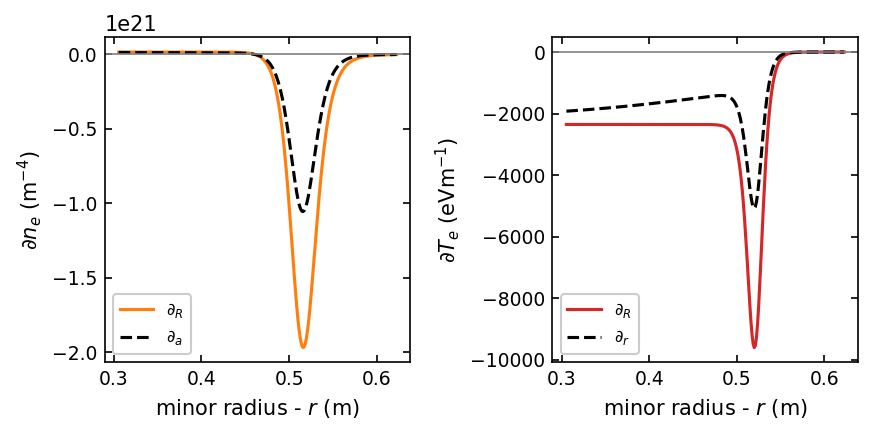

In [3]:
minorRadius = HSV.getMinorRadius(shotn, time[t], R, np.zeros(len(R)), Rmax=1.5, mastu_prefix='epq')

# fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
# ax.plot(np.diff(R), np.diff(minorRadius), 'o', c='C0', mfc='None')
# ax.set_xlabel('d$R$')
# ax.set_ylabel('d$r$')
# ax.tick_params(
#     axis="both", which='both', labelsize=9, direction='in', 
#     left=True, bottom=True, right=True, top=True
# )
# ax.minorticks_on()
# plt.tight_layout()

gradneMinor = np.gradient(profile2ne, minorRadius)
gradTeMinor = np.gradient(profile2Te, minorRadius)


fig, ax = plt.subplots(1, 2, figsize=(6,3), dpi=150)

ax[0].plot(minorRadius, gradneNumerical, c='C1', label='$\\partial_R$')
ax[0].plot(minorRadius, gradneMinor, '--', c='k', label='$\\partial_a$')
ax[0].set_xlabel('minor radius - $r$ (m)')
ax[0].set_ylabel('$\\partial n_e$ (m$^{-4}$)')

ax[0].legend(fancybox=1, framealpha=1, fontsize=8)
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].set_xlim(ax[0].get_xlim())
ax[0].plot(ax[0].get_xlim(), [0.,0.], '-', c='gray', lw=0.8)

ax[1].plot(minorRadius, gradTeNumerical, c='C3', label='$\\partial_R$')
ax[1].plot(minorRadius, gradTeMinor, '--', c='k', label='$\\partial_r$')
ax[1].set_xlabel('minor radius - $r$ (m)')
ax[1].set_ylabel('$\\partial T_e$ (eVm$^{-1}$)')

ax[1].legend(fancybox=1, framealpha=1, fontsize=8)
ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].set_xlim(ax[1].get_xlim())
ax[1].plot(ax[1].get_xlim(), [0.,0.], '-', c='gray', lw=0.8)


plt.tight_layout()


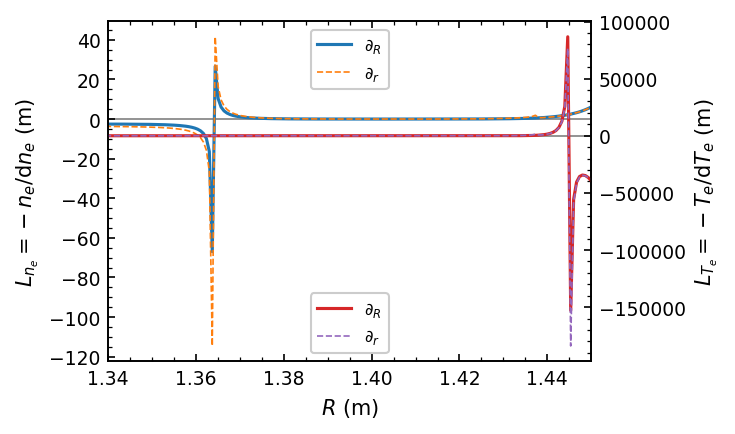

In [4]:
Lne = -profile2ne / gradne
LTe = -profile2Te / gradTe
LneMinor = -profile2ne / gradneMinor
LTeMinor = -profile2Te / gradTeMinor

xlim2 = (1.34, 1.45)

fig, ax = plt.subplots(1, 1, figsize=(5,3), dpi=150)
ax.plot(R, Lne, '-', c='C0', label='$\\partial_R$')
ax.plot(R, LneMinor, '--', c='C1', lw=0.8, label='$\\partial_r$')
ax.set_xlabel('$R$ (m)')
ax.set_ylabel('$L_{n_e} = -n_e / \\mathrm{d} n_e$ (m)')
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=False, top=True
)
ax.minorticks_on()
ax.legend(fancybox=1, framealpha=1, fontsize=8, loc='upper center')
ax.set_xlim(xlim2)
ax2 = ax.twinx()
ax2.plot(R, LTe, '-', c='C3', label='$\\partial_R$')
ax2.plot(R, LTeMinor, '--', c='C4', lw=0.8, label='$\\partial_r$')
ax2.set_ylabel('$L_{T_e} = -T_e / \\mathrm{d} T_e$ (m)')
ax2.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=False, bottom=False, right=True, top=False
)
ax2.minorticks_on()
ax2.legend(fancybox=1, framealpha=1, fontsize=8, loc='lower center')
ax.plot(xlim2, [0.,0.], '-', c='gray', lw=0.8, zorder=0)
ax2.plot(xlim2, [0.,0.], '-', c='gray', lw=0.8, zorder=0)
plt.tight_layout()

plt.savefig(f'/home/sthoma/Documents/MU04/EST-05/{shotn}_{twant:.4f}s_02.png')

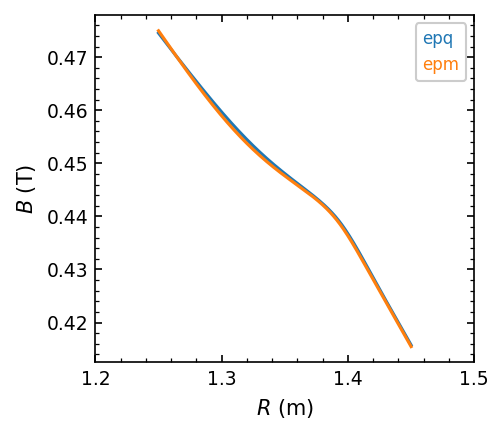

In [18]:
# eq = equil(device='MASTU', shot=shotn, time=twant, mastu_prefix='epq')
# eq_epm = equil(device='MASTU', shot=shotn, time=twant, mastu_prefix='epm')
eq = equil(device='MASTU', time=0.8, 
    efitpp_file='/common/projects/codes/equilibrium/efit++/mast_data/runs_epq/mastu/50936/efit_sgibson_01/epq050936.nc'
)
eq_epm = equil(device='MASTU', time=0.8, 
    efitpp_file='/common/projects/codes/equilibrium/efit++/mast_data/runs_epq/mastu/50936/efit_sgibson_02/epq050936.nc'
)

B = eq.B(R, 0.)[0]
B_eqm = eq_epm.B(R, 0.)[0]

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot(R, B, label='epq')
ax.plot(R, B_eqm, label='epm')
ax.legend(
    fancybox=1, framealpha=1, fontsize=8, 
    handlelength=0, handletextpad=0, labelcolor='linecolor'
)
ax.set_xlabel('$R$ (m)')
ax.set_ylabel('$B$ (T)')
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.minorticks_on()
ax.set_xlim(xlim)
plt.tight_layout()

plt.savefig(f'/home/sthoma/Documents/MU04/EST-05/{shotn}_{twant:.4f}s_03.png')

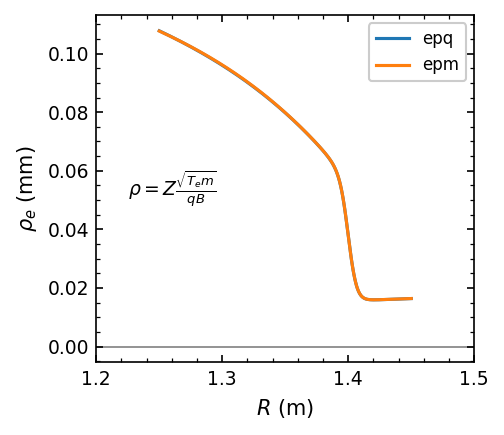

In [19]:
gyro_e = mf.gyroradius(profile2Te, B, Z=1, m=1., q=1., units='eV', particle='electron')
gyro_e_epm = mf.gyroradius(profile2Te, B_eqm, Z=1, m=1., q=1., units='eV', particle='electron')

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot(R, gyro_e*1e3, label='epq')
ax.plot(R, gyro_e_epm*1e3, label='epm')
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.plot(xlim, [0.,0.], '-', c='gray', lw=0.8, zorder=0)
ax.set_xlabel('$R$ (m)')
ax.set_ylabel('$\\rho_e$ (mm)')
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.set_xlim(xlim)
ax.minorticks_on()
ax.text(
    xlim[0]+0.025, np.mean(ax.get_ylim()), 
    '$\\rho=Z\\frac{\\sqrt{T_e m}}{qB}$',
    ha='left', va='center', fontsize=9
)
plt.tight_layout()

plt.savefig(f'/home/sthoma/Documents/MU04/EST-05/{shotn}_{twant:.4f}s_04.png')

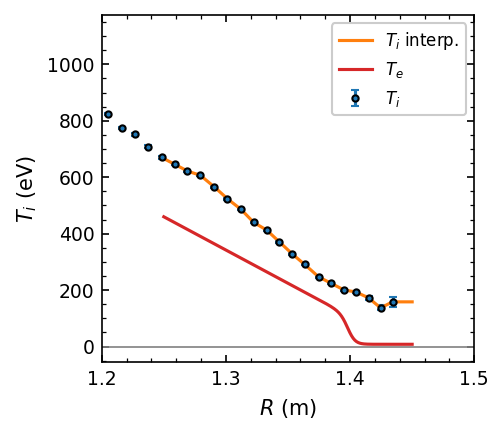

In [20]:
timeCX, RCX, dataCX, errCX = mf.getCXTi(shotn, prnt=False)

tindCX = fn.findNearest(timeCX, twant)
timeCX = timeCX[tindCX]
dataCX = dataCX[tindCX]
errCX = errCX[tindCX]

booCX = np.isfinite(dataCX)
dataCXinterp = np.interp(R, RCX[booCX], dataCX[booCX], )

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.errorbar(RCX, dataCX, yerr=errCX, fmt='.', c='C0', capsize=2, mec='k', label='$T_i$')
ax.plot(R, dataCXinterp, '-', c='C1', label='$T_i$ interp.')
ax.plot(R, profile2Te, '-', c='C3', label='$T_e$')
ax.legend(fancybox=1, framealpha=1, fontsize=8, )
ax.set_xlabel('$R$ (m)')
ax.set_ylabel('$T_i$ (eV)')
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.minorticks_on()
ax.set_xlim(xlim)
ax.plot(xlim, [0.,0.], '-', c='gray', lw=0.8)

plt.tight_layout()

plt.savefig(f'/home/sthoma/Documents/MU04/EST-05/{shotn}_{twant:.4f}s_05.png')

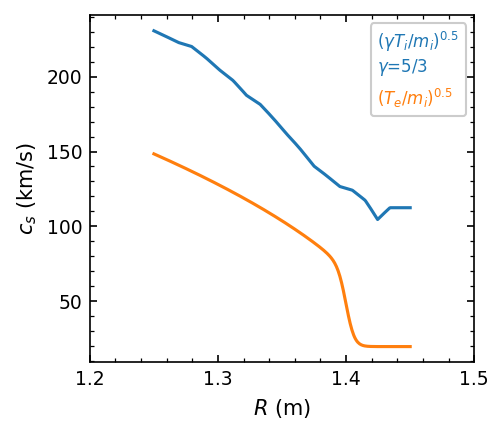

In [21]:
cs = mf.sound_speed(dataCXinterp, Z=1, mi=2., gamma=5./3., units='eV')
cs_electron = mf.sound_speed(profile2Te, Z=1, mi=2., gamma=1., units='eV')

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot(R, cs/1e3, label='$\\left( \\gamma T_i / m_i \\right)^{0.5}$\n$\\gamma$=5/3')
ax.plot(R, cs_electron/1e3, label='$\\left(T_e / m_i \\right)^{0.5}$')
ax.set_xlabel('$R$ (m)')
ax.set_ylabel('$c_s$ (km/s)')
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.legend(
    fancybox=1, framealpha=1, fontsize=8, 
    handlelength=0, handletextpad=0, labelcolor='linecolor'
)
ax.minorticks_on()
ax.set_xlim(xlim)
# ax.text(
#     xlim[-1]-0.025, ax.get_ylim()[-1]*0.9, 
#     '$c_s=\\sqrt{\\frac{\\gamma Z T_i}{m_i}}$\nwhere $\\gamma=5/3$',
#     ha='right', va='top', fontsize=9
# )
plt.tight_layout()

plt.savefig(f'/home/sthoma/Documents/MU04/EST-05/{shotn}_{twant:.4f}s_06.png')

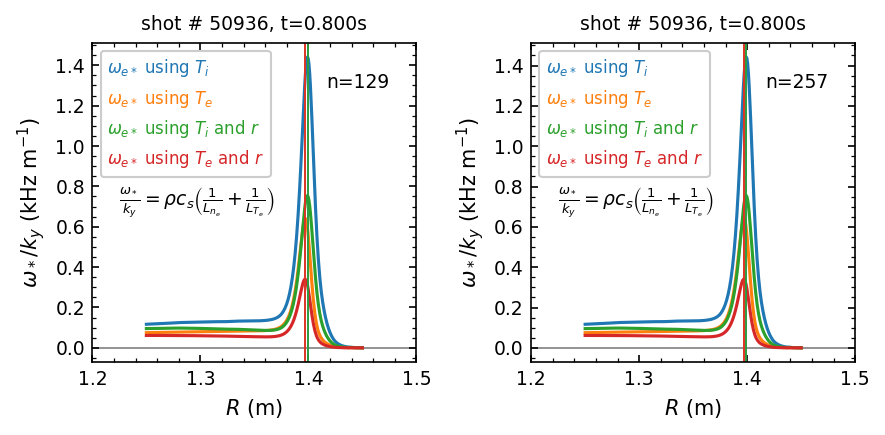

In [28]:
omega_star_e = gyro_e * cs * ((1. / Lne) + (1. / LTe))
omega_star_e_Te = gyro_e * cs_electron * ((1. / Lne) + (1. / LTe))
omega_star_e_minor = gyro_e * cs * ((1. / LneMinor) + (1. / LTeMinor))
omega_star_e_Te_minor = gyro_e * cs_electron * ((1. / LneMinor) + (1. / LTeMinor))

omega_star_e_epm = gyro_e_epm * cs * ((1. / Lne) + (1. / LTe))
omega_star_e_Te_epm = gyro_e_epm * cs_electron * ((1. / Lne) + (1. / LTe))
omega_star_e_minor_epm = gyro_e_epm * cs * ((1. / LneMinor) + (1. / LTeMinor))
omega_star_e_Te_minor_epm = gyro_e_epm * cs_electron * ((1. / LneMinor) + (1. / LTeMinor))

fig, ax = plt.subplots(1, 2, figsize=(6,3), dpi=150)
ax[0].plot(R, omega_star_e/1e3, label='$\\omega_{e*}$ using $T_i$')
ax[0].plot(R, omega_star_e_Te/1e3, label='$\\omega_{e*}$ using $T_e$')
ax[0].plot(R, omega_star_e_minor/1e3, label='$\\omega_{e*}$ using $T_i$ and $r$')
ax[0].plot(R, omega_star_e_Te_minor/1e3, label='$\\omega_{e*}$ using $T_e$ and $r$')
ax[0].legend(
    fancybox=1, framealpha=1, fontsize=8, 
    handlelength=0, handletextpad=0, labelcolor='linecolor'
)
ax[0].plot(xlim, [0.,0.], '-', c='gray', lw=0.8, zorder=0)
ax[0].set_xlabel('$R$ (m)')
ax[0].set_ylabel('$\\omega_* / k_y$ (kHz m$^{-1}$)')
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].minorticks_on()
ylim = ax[0].get_ylim()
ax[0].set_xlim(xlim)
ax[0].text(
    xlim[0]+0.025, np.mean(ylim), 
    '$\\frac{\\omega_*}{k_y} = \\rho c_s \\left(\\frac{1}{L_{n_e}} + \\frac{1}{L_{T_e}} \\right)$',
    ha='left', va='center', fontsize=9
)
ax[0].text(
    xlim[1]-0.025, ylim[1]*0.9, 
    'n=129', ha='right', va='top', fontsize=9
)
ax[0].set_ylim(ylim)
i = omega_star_e.argmax()
ax[0].plot([R[i],R[i]], ylim, '-', c='C0', lw=0.8)
i = omega_star_e_Te.argmax()
ax[0].plot([R[i],R[i]], ylim, '-', c='C1', lw=0.8)
i = omega_star_e_minor.argmax()
ax[0].plot([R[i],R[i]], ylim, '-', c='C2', lw=0.8)
i = omega_star_e_Te_minor.argmax()
ax[0].plot([R[i],R[i]], ylim, '-', c='C3', lw=0.8)
ax[0].set_title(f'shot # {shotn}, t={twant:.3f}s', fontsize=9)

ax[1].plot(R, omega_star_e_epm/1e3, label='$\\omega_{e*}$ using $T_i$')
ax[1].plot(R, omega_star_e_Te_epm/1e3, label='$\\omega_{e*}$ using $T_e$')
ax[1].plot(R, omega_star_e_minor_epm/1e3, label='$\\omega_{e*}$ using $T_i$ and $r$')
ax[1].plot(R, omega_star_e_Te_minor_epm/1e3, label='$\\omega_{e*}$ using $T_e$ and $r$')
ax[1].legend(
    fancybox=1, framealpha=1, fontsize=8, 
    handlelength=0, handletextpad=0, labelcolor='linecolor'
)
ax[1].plot(xlim, [0.,0.], '-', c='gray', lw=0.8, zorder=0)
ax[1].set_xlabel('$R$ (m)')
ax[1].set_ylabel('$\\omega_* / k_y$ (kHz m$^{-1}$)')
ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].minorticks_on()
ylim = ax[1].get_ylim()
ax[1].set_xlim(xlim)
ax[1].text(
    xlim[0]+0.025, np.mean(ylim), 
    '$\\frac{\\omega_*}{k_y} = \\rho c_s \\left(\\frac{1}{L_{n_e}} + \\frac{1}{L_{T_e}} \\right)$',
    ha='left', va='center', fontsize=9
)
ax[1].text(
    xlim[1]-0.025, ylim[1]*0.9, 
    'n=257', ha='right', va='top', fontsize=9
)
ax[1].set_ylim(ylim)
i = omega_star_e_epm.argmax()
ax[1].plot([R[i],R[i]], ylim, '-', c='C0', lw=0.8)
i = omega_star_e_Te_epm.argmax()
ax[1].plot([R[i],R[i]], ylim, '-', c='C1', lw=0.8)
i = omega_star_e_minor_epm.argmax()
ax[1].plot([R[i],R[i]], ylim, '-', c='C2', lw=0.8)
i = omega_star_e_Te_minor_epm.argmax()
ax[1].plot([R[i],R[i]], ylim, '-', c='C3', lw=0.8)
ax[1].set_title(f'shot # {shotn}, t={twant:.3f}s', fontsize=9)

plt.tight_layout()
plt.savefig(f'/home/sthoma/Documents/MU04/EST-05/{shotn}_{twant:.4f}s_07.png')

In [23]:
# np.savetxt(f'/home/sthoma/Documents/MU04/EST-05/{shotn}_{twant:.4f}s_results.txt', np.vstack((R, omega_star_e)).T)

In [24]:
def forward(x):
    return np.interp(x, R, psiN)
def inverse(x):
    return np.interp(x, psiN, R)

In [25]:
psiN = eq.psiN(R, 0.01)[0]
psi = eq.psi(R, 0.01)[0]
qprofile = np.zeros_like(psi)
for i in range(0, len(psi)):
    try:
        qprofile[i] = -eq.qpsi(psi[i])
    except ValueError:
        pass
qboo = ~np.isclose(qprofile, 0.)
Rsep = np.interp(1., psiN, R)

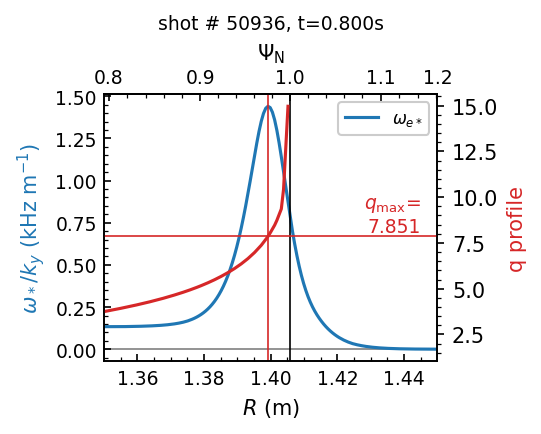

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)

ax.plot(R, omega_star_e/1e3, label='$\\omega_{e*}$')
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.plot(xlim, [0.,0.], '-', c='gray', lw=0.8, zorder=0)
ax.set_xlabel('$R$ (m)')
ax.set_ylabel('$\\omega_* / k_y$ (kHz m$^{-1}$)', c='C0')
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=False, top=False
)
ax.minorticks_on()
ax.set_xlim((1.35,1.45))
ax.set_title(f'shot # {shotn}, t={twant:.3f}s', fontsize=9)


secax = ax.secondary_xaxis('top', functions=(forward, inverse))
secax.set_xlabel('$\\Psi_\\mathrm{N}$')
secax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
            left=False, bottom=False, right=False, top=True
)
secax.minorticks_on()


ax2 = ax.twinx()
ax2.plot(R[qboo], qprofile[qboo], c='C3')
ax2.set_ylabel('q profile', c='C3')
ax2.minorticks_on()


ylim = ax.get_ylim()
ax.set_ylim(ylim)
ax.plot([Rsep,Rsep], ylim, '-k', lw=0.8)

maxind = omega_star_e.argmax()
q_peak = qprofile[maxind]
ax.plot([R[maxind],R[maxind]], ylim, c='C3', lw=0.8)
ax2.plot(xlim, [q_peak,q_peak], c='C3', lw=0.8)
ax2.text(
    1.445, q_peak, f'$q_\\mathrm{{max}}$=\n{q_peak:.3f}', 
    color='C3', ha='right', va='bottom', fontsize=9
)


plt.tight_layout()

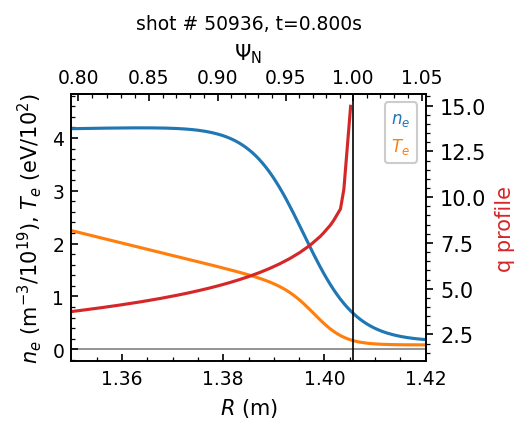

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)

ax.plot(R, profile2ne/1e19, label='$n_e$')
ax.plot(R, profile2Te/100., label='$T_e$')
ax.legend(
    fancybox=1, framealpha=1, fontsize=8, 
    handlelength=0, handletextpad=0, labelcolor='linecolor'
)
ax.plot(xlim, [0.,0.], '-', c='gray', lw=0.8, zorder=0)
ax.set_xlabel('$R$ (m)')
ax.set_ylabel('$n_e$ (m$^{-3}$/10$^{19}$), $T_e$ (eV/10$^2$)')
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=False, top=False
)
ax.minorticks_on()
ax.set_xlim((1.35,1.42))
ax.set_title(f'shot # {shotn}, t={twant:.3f}s', fontsize=9)


secax = ax.secondary_xaxis('top', functions=(forward, inverse))
secax.set_xlabel('$\\Psi_\\mathrm{N}$')
secax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
            left=False, bottom=False, right=False, top=True
)
secax.minorticks_on()


ax2 = ax.twinx()
ax2.plot(R[qboo], qprofile[qboo], c='C3')
ax2.set_ylabel('q profile', c='C3')
ax2.minorticks_on()


ylim = ax.get_ylim()
ax.set_ylim(ylim)
ax.plot([Rsep,Rsep], ylim, '-k', lw=0.8)


plt.tight_layout()

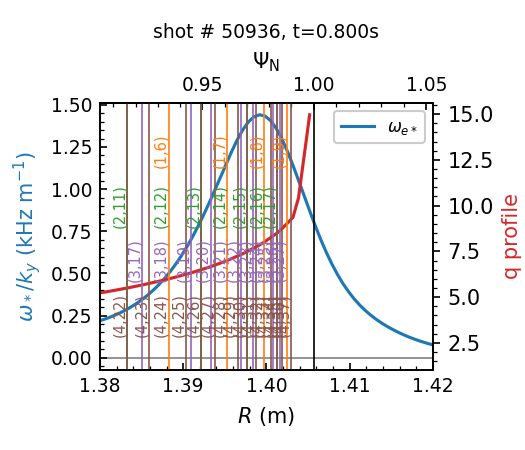

In [61]:
def qplot(ax, n, m, qprofile, R, ytext):
    qwant = float(m / n)
    if n >= 3:
        c=n+1
    else:
        c=n
    Rwant = np.interp(qwant, qprofile, R)
    ylim = ax.get_ylim()
    if (n==1) or (not m%n == 0):
        ax.plot([Rwant, Rwant], ylim, '-', c=f'C{c}', lw=0.8)
    ax.text(Rwant, ytext, f'({n},{m})', fontsize=7, c=f'C{c}', ha='right', va='center', rotation=90)
    return

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)

ax.plot(R, omega_star_e/1e3, label='$\\omega_{e*}$')
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.plot(xlim, [0.,0.], '-', c='gray', lw=0.8, zorder=0)
ax.set_xlabel('$R$ (m)')
ax.set_ylabel('$\\omega_* / k_y$ (kHz m$^{-1}$)', c='C0')
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=False, top=False
)
ax.minorticks_on()
# ax.set_xlim((1.35,1.45))
ax.set_xlim((1.38,1.42))
ax.set_title(f'shot # {shotn}, t={twant:.3f}s', fontsize=9)


secax = ax.secondary_xaxis('top', functions=(forward, inverse))
secax.set_xlabel('$\\Psi_\\mathrm{N}$')
secax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
            left=False, bottom=False, right=False, top=True
)
secax.minorticks_on()


ax2 = ax.twinx()
ax2.plot(R[qboo], qprofile[qboo], c='C3')
ax2.set_ylabel('q profile', c='C3')
ax2.minorticks_on()
ax2.set_ylim(ax2.get_ylim())


ylim = ax.get_ylim()
ax.set_ylim(ylim)
ax.plot([Rsep,Rsep], ylim, '-k', lw=0.8)



for i in range(6, 10):
    qplot(ax2, 1, i, qprofile[qboo], R[qboo], 13.)
for i in range(11, 18):
    qplot(ax2, 2, i, qprofile[qboo], R[qboo], 10.)
for i in range(17, 28):
    qplot(ax2, 3, i, qprofile[qboo], R[qboo], 7.)
for i in range(22, 38):
    qplot(ax2, 4, i, qprofile[qboo], R[qboo], 4.)

plt.tight_layout()

In [ ]:
qprofile